<a href="https://colab.research.google.com/github/anupbagale/Whole-Brain-Segmentation/blob/main/Whole_brain_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!python -c "import monai" || pip install -q "monai-weekly[gdown, nibabel, tqdm, ignite]"
!python -c "import matplotlib" || pip install -q matplotlib
%matplotlib inline

Traceback (most recent call last):
  File "<string>", line 1, in <module>
ModuleNotFoundError: No module named 'monai'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.5/266.5 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 843.0 kB/s eta 0:00:00


In [ ]:
import os
import numpy as np
import torch
from torch.utils.data import DataLoader
from monai.apps import DecathlonDataset
from monai.transforms import (
    AsDiscrete,
    Compose,
    AsDiscreted,
    EnsureChannelFirstd,
    Compose,
    CropForegroundd,
    LoadImaged,
    Orientationd,
    RandCropByPosNegLabeld,
    SaveImaged,
    ScaleIntensityd,
    Spacingd,
    Invertd,
    ToTensord,
    Resized,
    Lambdad,
)
from monai.networks.nets import UNet
from monai.metrics import DiceMetric
from monai.losses import DiceLoss
from monai.inferers import sliding_window_inference
from monai.data import decollate_batch, DataLoader, Dataset
from monai.transforms import AsDiscrete
from monai.config import print_config
from monai.data import Dataset, DataLoader, CacheDataset, load_decathlon_datalist, decollate_batch
from monai.handlers.utils import from_engine
from monai.networks.layers import Norm
from monai.config import print_config
from monai.apps import download_and_extract
import tempfile
from glob import glob
from tqdm import tqdm
import matplotlib.pyplot as plt
from monai.utils import set_determinism
import shutil

from monai.apps import download_and_extract
import torch
import matplotlib.pyplot as plt
import os
from glob import glob
import numpy as np
import nibabel as nib

from matplotlib import colors
import nibabel as nib

print_config()

MONAI version: 1.4.dev2431
Numpy version: 1.26.4
Pytorch version: 2.3.1+cu121
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: 951a77d7a7737a3108afa94623a50b87d21eb4a7
MONAI __file__: /usr/local/lib/python3.10/dist-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: 0.4.11
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: 5.0.1
scikit-image version: 0.23.2
scipy version: 1.13.1
Pillow version: 9.4.0
Tensorboard version: 2.17.0
gdown version: 4.7.3
TorchVision version: 0.18.1+cu121
tqdm version: 4.66.5
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 5.9.5
pandas version: 2.1.4
einops version: 0.8.0
transformers version: 4.42.4
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKNOWN VERSION.
clearml version: NOT INSTALLED or UNKNOWN VERSION.

For details about installing the optional dependencies, please visit:
    https://docs.monai.io/en/latest/installation.htm

In [ ]:
drive_directory = '/content/drive/MyDrive/MONAI_DATA_DIRECTORY'

os.makedirs(drive_directory, exist_ok=True)

directory = drive_directory if os.path.exists(drive_directory) else os.environ.get("MONAI_DATA_DIRECTORY")
root_dir = directory if directory is not None else tempfile.mkdtemp()

print(f"The directory has been set to: {root_dir}")


The directory has been set to: /content/drive/MyDrive/MONAI_DATA_DIRECTORY


In [ ]:
image_directory='/content/drive/MyDrive/OASIS3_Dataset_Part4-20240506T062954Z-001/OASIS3_Dataset_Part4/Image_Folder'
label_directory='/content/drive/MyDrive/OASIS3_Dataset_Part4-20240506T062954Z-001/OASIS3_Dataset_Part4/Label_Folder'

In [ ]:
image_files=sorted(glob(f'{image_directory}/**/*.nii.gz*',recursive=True))
label_files=sorted(glob(f'{label_directory}/**/*.nii.gz*',recursive=True))

In [ ]:
colormap_path = '/content/drive/MyDrive/FreeSurferColorLUT.txt'

In [ ]:
STD_LABEL_VALUES=np.array([0,2,3,4,5,7,8,10,11,12,13,14,15,16,17,18,24,26,28,30,31,41,42,43,44,46,47,49,50,51,52,53,54,58,60,62,63,77,80,85,251,252,253,254,255])

data=np.loadtxt(colormap_path,dtype=str)
label_index=data[:,0].astype(np.int16)
label_cmap=data[:,2:5].astype(np.int16)/255
cmap_array=np.zeros((45,3))
for i,label in zip(range(len(STD_LABEL_VALUES)),STD_LABEL_VALUES):
  Loc=np.where(label_index==label)[0][0]
  cmap_array[i]=label_cmap[Loc]

In [ ]:
def Replace_FS_Index(Label_data):
  for items in STD_LABEL_VALUES:
    Label_data[Label_data==items]=np.where(STD_LABEL_VALUES==items)[0][0]
  return Label_data

In [ ]:
patient_data=[{'image':images,'label':labels} for images,labels in zip(image_files,label_files)]
train_data=patient_data[:118]
val_data=patient_data[118:]
print(f'Size of Train Files=',len(train_data),'\n Size of Validation Files=',len(val_data))

Size of Train Files= 118 
 Size of Validation Files= 30


In [ ]:
set_determinism(seed=0)

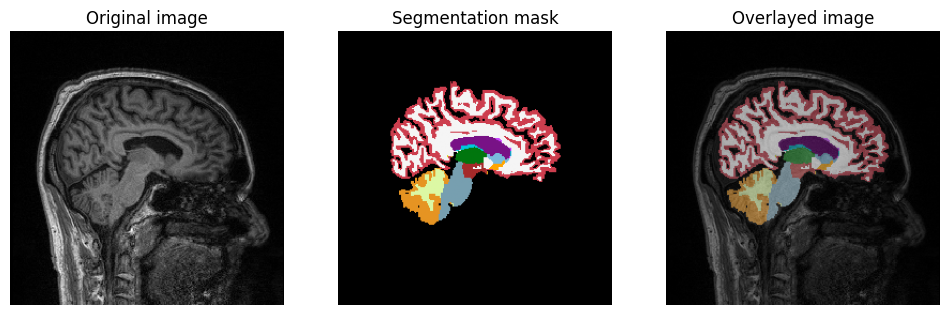

In [ ]:
img_data=nib.load(image_files[0]).get_fdata()
label_data=nib.load(label_files[0]).get_fdata()
mod_label_data=Replace_FS_Index(label_data)
colored_label_data=cmap_array[mod_label_data.astype(np.int16)]

plt.figure(figsize=(12,7))
plt.subplot(1,3,1)
plt.imshow(img_data[118,:,:],cmap='gray')
plt.axis('off')
plt.title("Original image")

plt.subplot(1,3,2)
plt.imshow(colored_label_data[118,:,:])
plt.axis('off')
plt.title("Segmentation mask")

plt.subplot(1,3,3)
plt.imshow(img_data[118,:,:],cmap='gray')
plt.imshow(colored_label_data[118,:,:], alpha= 0.5)
plt.axis('off')
plt.title("Overlayed image")
plt.show()


In [ ]:
ext_img_data=np.expand_dims(img_data,axis=0)
ext_label_data=np.expand_dims(label_data,axis=0)

In [ ]:
std_train_transforms = Compose(
    [
        LoadImaged(keys=["image", "label"]),
        Lambdad(keys="label",func=Replace_FS_Index),
        ToTensord(keys=["image", "label"]),
        EnsureChannelFirstd(keys=["image", "label"]),
        Resized(keys=["image","label"],spatial_size=(128,128,128),mode=['area','nearest']),
        ScaleIntensityd(keys="image", minv=0, maxv=1),
    ]
)
std_val_transforms = Compose(
    [
        LoadImaged(keys=["image", "label"]),
        Lambdad(keys="label",func=Replace_FS_Index),
        ToTensord(keys=["image", "label"]),
        EnsureChannelFirstd(keys=["image", "label"]),
        Resized(keys=["image","label"],spatial_size=(128,128,128),mode=['area','nearest']),
        ScaleIntensityd(keys="image", minv=0, maxv=1),
    ]
)


In [ ]:
BATCH_SIZE=2

train_ds = Dataset(data=train_data, transform=std_train_transforms)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

val_ds = Dataset(data=val_data, transform=std_val_transforms)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, num_workers=0, shuffle=False)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=45,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
    norm=Norm.BATCH,
).to(device)

loss_function = DiceLoss(to_onehot_y=True, softmax=True)
optimizer = torch.optim.Adam(model.parameters(), 1e-3)
dice_metric = DiceMetric(include_background=False, reduction="mean")
voe_metric = VolumeOverlapError()
iou_metric = IntersectionOverUnion()

cuda


In [ ]:
max_epochs = 60
val_interval = 2
early_stopping_patience = 10
best_metric = -1
best_metric_epoch = -1
epoch_loss_values = []
metric_values = []
post_pred = Compose([AsDiscrete(argmax=True, to_onehot=45)])
post_label = Compose([AsDiscrete(to_onehot=45)])
early_stop_counter = 0

# Initialize metrics
dice_metric = DiceMetric(include_background=True, reduction="mean")

# Function to save checkpoint
def save_checkpoint(model, optimizer, epoch, best_metric, best_metric_epoch, path, epoch_loss_values):
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'best_metric': best_metric,
        'best_metric_epoch': best_metric_epoch,
        'epoch_loss_values': epoch_loss_values  # Save epoch_loss_values
    }, path)

# Function to load checkpoint
def load_checkpoint(model, optimizer, path):
    checkpoint = torch.load(path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    epoch_loss_values = checkpoint.get('epoch_loss_values', [])  # Restore epoch_loss_values
    return checkpoint['epoch'], checkpoint['best_metric'], checkpoint['best_metric_epoch'], epoch_loss_values

# Path to save the checkpoint
checkpoint_path = os.path.join(root_dir, "checkpoint.pth")

# Load from checkpoint if exists
start_epoch = 0
if os.path.exists(checkpoint_path):
    start_epoch, best_metric, best_metric_epoch, epoch_loss_values = load_checkpoint(model, optimizer, checkpoint_path)
    print(f"Resuming from epoch {start_epoch}, best metric: {best_metric:.4f} at epoch {best_metric_epoch}")

for epoch in range(start_epoch, max_epochs):
    print("-" * 10)
    print(f"Epoch {epoch + 1}/{max_epochs}")
    model.train()
    epoch_loss = 0
    step = 0
    for batch_data in train_loader:
        step += 1
        inputs, labels = (
            batch_data["image"].to(device),
            batch_data["label"].to(device),
        )
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        print(f"{step}/{len(train_ds) // train_loader.batch_size}, train_loss: {loss.item():.4f}")
    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)
    print(f"Epoch {epoch + 1} average loss: {epoch_loss:.4f}")

    if (epoch + 1) % val_interval == 0:
        model.eval()
        with torch.no_grad():
            for val_data in val_loader:
                val_inputs, val_labels = (
                    val_data["image"].to(device),
                    val_data["label"].to(device),
                )
                roi_size = (128, 128, 128)
                sw_batch_size = 4
                val_outputs = sliding_window_inference(val_inputs, roi_size, sw_batch_size, model)
                val_outputs = [post_pred(i) for i in decollate_batch(val_outputs)]
                val_labels = [post_label(i) for i in decollate_batch(val_labels)]
                dice_metric(y_pred=val_outputs, y=val_labels)

            # Aggregate the final mean dice result
            metric = dice_metric.aggregate().item()
            # Reset the status for next validation round
            dice_metric.reset()

            metric_values.append(metric)
            if metric > best_metric:
                best_metric = metric
                best_metric_epoch = epoch + 1

                save_checkpoint(model, optimizer, epoch + 1, best_metric, best_metric_epoch, os.path.join(root_dir, "best_metric_model.pth"), epoch_loss_values)
                print("Saved new best metric model")
                early_stop_counter = 0  # Reset the early stop counter if we get a new best metric
            else:
                early_stop_counter += 1  # Increment the early stop counter if no improvement

            print(
                f"Current epoch: {epoch + 1} current mean dice: {metric:.4f}"
                f"\nBest mean dice: {best_metric:.4f} at epoch: {best_metric_epoch}"
            )

    # Save checkpoint every epoch
    save_checkpoint(model, optimizer, epoch + 1, best_metric, best_metric_epoch, checkpoint_path, epoch_loss_values)

    # Early stopping
    if early_stop_counter >= early_stopping_patience:
        print(f"Early stopping triggered after {epoch + 1} epochs.")
        break

print(f"Training completed. Best metric: {best_metric:.4f} at epoch {best_metric_epoch}")

In [ ]:
import matplotlib.pyplot as plt

# Plot the training loss and validation Dice score
plt.figure(figsize=(12, 6))

# Plotting training loss over epochs
plt.subplot(1, 2, 1)  # Changed to 1, 2, 1 to plot side by side
plt.plot(range(1, len(epoch_loss_values) + 1), epoch_loss_values, label='Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()

# Plotting validation Dice score over epochs
plt.subplot(1, 2, 2)  # Changed to 1, 2, 2 to plot side by side
plt.plot(range(val_interval, len(metric_values) * val_interval + 1, val_interval), metric_values, label='Validation Dice', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Dice Score')
plt.title('Validation Dice Score Over Epochs')
plt.legend()

plt.tight_layout()
plt.show()


torch.Size([2, 1, 128, 128, 128])


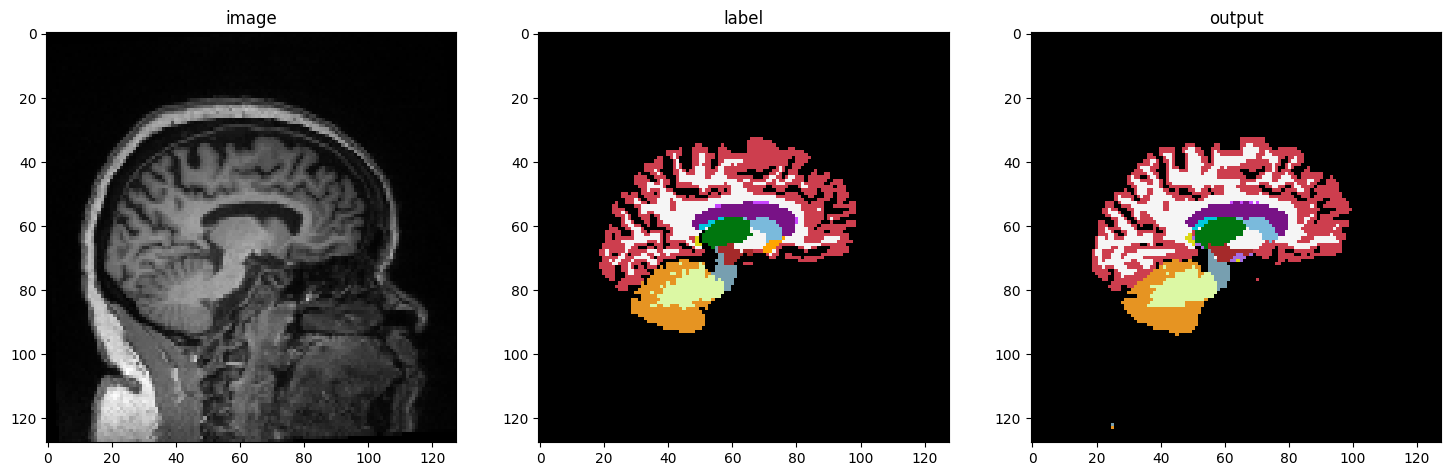

In [ ]:
checkpoint = torch.load(os.path.join(root_dir, "best_metric_model.pth"))

# Load the model state dictionary from the checkpoint
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Perform evaluation and visualization
with torch.no_grad():
    for i, val_data in enumerate(val_loader):
        print(val_data['image'].shape)
        roi_size = (128, 128, 128)
        sw_batch_size = 4
        val_outputs = sliding_window_inference(val_data["image"].to(device), roi_size, sw_batch_size, model)

        # Plot the slice [:, :, 59]
        plt.figure("check", (18, 6))
        plt.subplot(1, 3, 1)
        plt.title(f"image")
        plt.imshow(val_data["image"][0, 0, 59, :, :].detach().cpu(), cmap="gray")

        plt.subplot(1, 3, 2)
        plt.title(f"label")
        col_val_data = cmap_array[val_data["label"][0, 0, :, :, :].detach().cpu().numpy().astype(np.int16)]
        plt.imshow(col_val_data[59, :, :])

        plt.subplot(1, 3, 3)
        plt.title(f"output")
        col_val_out = cmap_array[torch.argmax(val_outputs, dim=1)[0, :, :, :].detach().cpu().numpy().astype(np.int16)]
        plt.imshow(col_val_out[59, :, :])

        plt.show()

        if i == 0:
            break